In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
import scipy.io as sio
matfile = 'Dp_current_clamp_linscale.mat'
mat = sio.loadmat(matfile)

In [17]:
import pandas as pd
ccdf = pd.DataFrame(mat['rawDataMatrix'])
# Convert the datatype to float
ccdf = ccdf.astype(float)


In [18]:
# Set each two rows as opto and hyperpol
ccdf['stimulus_type'] = ['hyperpol' if i % 2 == 0 else 'opto' for i in range(ccdf.shape[0])]
# Set stimulus_type as index level
ccdf = ccdf.set_index('stimulus_type', append=True)
# Set name of the column level as time
ccdf.columns.names = ['time']
ccdf


,time,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
,stimulus_type,,,,,,,,,,,,,,,,,,,,,
0,hyperpol,0.006290,-0.003449,-0.011886,-0.015717,-0.021641,-0.026384,-0.030864,-0.034178,-0.038334,-0.040565,...,-0.968533,-0.968109,-0.967384,-0.966604,-0.969725,-0.969294,-0.969940,-0.970480,-0.971198,-0.971251
1,opto,0.018120,0.020947,0.021789,0.016277,0.018808,0.018163,0.020805,0.021818,0.021430,0.020145,...,-0.980331,-0.979301,-0.980330,-0.978009,-0.976357,-0.979142,-0.982198,-0.982000,-0.981404,-0.981473
2,hyperpol,0.033198,0.022355,0.010869,0.004617,-0.002306,-0.007189,-0.010737,-0.013901,-0.019249,-0.023757,...,-1.010205,-1.012326,-1.013487,-1.011485,-1.012890,-1.012865,-1.013449,-1.013170,-1.014672,-1.016416
3,opto,-0.035701,-0.034316,-0.031366,-0.031356,-0.032508,-0.033558,-0.032915,-0.031938,-0.033048,-0.033693,...,-0.984250,-0.983528,-0.984895,-0.983841,-0.985129,-0.984533,-0.983739,-0.982626,-0.983814,-0.985774
4,hyperpol,0.007689,-0.001496,-0.008842,-0.013927,-0.018426,-0.022063,-0.025996,-0.029612,-0.033161,-0.036585,...,-0.983105,-0.982165,-0.982540,-0.982036,-0.981253,-0.982013,-0.981637,-0.981955,-0.981683,-0.982284
5,opto,0.027028,0.029075,0.030728,0.030494,0.029523,0.029978,0.029209,0.030761,0.031564,0.032041,...,-0.981181,-0.981318,-0.981548,-0.982416,-0.981580,-0.982064,-0.982892,-0.982394,-0.981492,-0.980853
6,hyperpol,0.068878,0.061872,0.052353,0.045112,0.039251,0.034794,0.030818,0.027286,0.023469,0.018069,...,-1.014033,-1.016031,-1.016112,-1.017436,-1.016432,-1.016028,-1.015372,-1.014336,-1.014964,-1.016412
7,opto,-0.019968,-0.020180,-0.020936,-0.019746,-0.025472,-0.030620,-0.026642,-0.028719,-0.027705,-0.022899,...,-1.110642,-1.111884,-1.105836,-1.109377,-1.113870,-1.113706,-1.110479,-1.111620,-1.111760,-1.112135
8,hyperpol,0.077919,0.068657,0.059691,0.055248,0.050766,0.045282,0.041410,0.037342,0.032805,0.028799,...,-0.960133,-0.961377,-0.962815,-0.962227,-0.963138,-0.964130,-0.964465,-0.963013,-0.964548,-0.967712


In [19]:
neuron_ids = list(range(0,17))
# Repeat each neuron 2 times
neuron_ids = [nid for nid in neuron_ids for _ in range(2)]
neuron_ids

ccdf['neuron_id'] = neuron_ids
ccdf = ccdf.set_index('neuron_id', append=True)
# Remove first level of ccdf.index
ccdf.index = ccdf.index.droplevel(0)
ccdf

,time,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
stimulus_type,neuron_id,,,,,,,,,,,,,,,,,,,,,
hyperpol,0,0.006290,-0.003449,-0.011886,-0.015717,-0.021641,-0.026384,-0.030864,-0.034178,-0.038334,-0.040565,...,-0.968533,-0.968109,-0.967384,-0.966604,-0.969725,-0.969294,-0.969940,-0.970480,-0.971198,-0.971251
opto,0,0.018120,0.020947,0.021789,0.016277,0.018808,0.018163,0.020805,0.021818,0.021430,0.020145,...,-0.980331,-0.979301,-0.980330,-0.978009,-0.976357,-0.979142,-0.982198,-0.982000,-0.981404,-0.981473
hyperpol,1,0.033198,0.022355,0.010869,0.004617,-0.002306,-0.007189,-0.010737,-0.013901,-0.019249,-0.023757,...,-1.010205,-1.012326,-1.013487,-1.011485,-1.012890,-1.012865,-1.013449,-1.013170,-1.014672,-1.016416
opto,1,-0.035701,-0.034316,-0.031366,-0.031356,-0.032508,-0.033558,-0.032915,-0.031938,-0.033048,-0.033693,...,-0.984250,-0.983528,-0.984895,-0.983841,-0.985129,-0.984533,-0.983739,-0.982626,-0.983814,-0.985774
hyperpol,2,0.007689,-0.001496,-0.008842,-0.013927,-0.018426,-0.022063,-0.025996,-0.029612,-0.033161,-0.036585,...,-0.983105,-0.982165,-0.982540,-0.982036,-0.981253,-0.982013,-0.981637,-0.981955,-0.981683,-0.982284
opto,2,0.027028,0.029075,0.030728,0.030494,0.029523,0.029978,0.029209,0.030761,0.031564,0.032041,...,-0.981181,-0.981318,-0.981548,-0.982416,-0.981580,-0.982064,-0.982892,-0.982394,-0.981492,-0.980853
hyperpol,3,0.068878,0.061872,0.052353,0.045112,0.039251,0.034794,0.030818,0.027286,0.023469,0.018069,...,-1.014033,-1.016031,-1.016112,-1.017436,-1.016432,-1.016028,-1.015372,-1.014336,-1.014964,-1.016412
opto,3,-0.019968,-0.020180,-0.020936,-0.019746,-0.025472,-0.030620,-0.026642,-0.028719,-0.027705,-0.022899,...,-1.110642,-1.111884,-1.105836,-1.109377,-1.113870,-1.113706,-1.110479,-1.111620,-1.111760,-1.112135
hyperpol,4,0.077919,0.068657,0.059691,0.055248,0.050766,0.045282,0.041410,0.037342,0.032805,0.028799,...,-0.960133,-0.961377,-0.962815,-0.962227,-0.963138,-0.964130,-0.964465,-0.963013,-0.964548,-0.967712


In [20]:
# Save ccdf to csv
ccdf.to_csv('normalized_current_clamp.csv')

In [12]:
np.linspace(0, 300, 31)

array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.,
       110., 120., 130., 140., 150., 160., 170., 180., 190., 200., 210.,
       220., 230., 240., 250., 260., 270., 280., 290., 300.])

/tmp/ipykernel_3150805/2500540051.py:13: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  ccdf_binned = ccdf.groupby(pd.cut(ccdf.columns, bins=range(0, total_time + bin_size, bin_size), right=False), axis=1).mean()
/tmp/ipykernel_3150805/2500540051.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ccdf_binned = ccdf.groupby(pd.cut(ccdf.columns, bins=range(0, total_time + bin_size, bin_size), right=False), axis=1).mean()


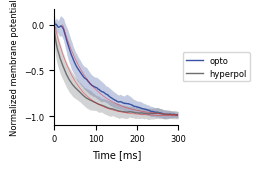

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from catrace.plot_trace import plot_mean_with_std

fig, ax = plt.subplots(figsize=(2.7, 1.8))
original_frame_rate = 10
fontsize = 7
legend_fontsize = 6

bin_size = 10
total_time = ccdf.shape[1]
# Bin along the time axis with bin_size
ccdf_binned = ccdf.groupby(pd.cut(ccdf.columns, bins=range(0, total_time + bin_size, bin_size), right=False), axis=1).mean()
# Renumber columns from 0 to total_number_of_bins
ccdf_binned.columns = range(ccdf_binned.shape[1])
ccdf_binned.columns.name = 'time'
frame_rate = original_frame_rate / bin_size

time_range = (0, 300)

import numpy as np
frame_range = np.array(time_range) * frame_rate
cut_ccdf_binned = ccdf_binned.loc[:, frame_range[0]:frame_range[1]]

plot_mean_with_std(cut_ccdf_binned.xs('opto', level='stimulus_type').T, frame_rate=frame_rate, ax=ax, color='#3953A4', label='opto', err_type='std')

plot_mean_with_std(cut_ccdf_binned.xs('hyperpol', level='stimulus_type').T, frame_rate=frame_rate, ax=ax, color='#6D6E71', label='hyperpol', err_type='std')

# Final touches
# ax.set_title('Normalized Time Course of OB and Dp Regions')
# Plot an exponential function with time constant of 65 ms
time_constant = 65
xvec = np.linspace(0, 300, 31)
yvec = np.exp(-xvec / time_constant)
yvec = yvec / yvec.max() - 1
# shift xvec by 20ms to the right
xvec_shifted = xvec + 20
ax.plot(xvec_shifted, yvec, color='red', linewidth=0.5, alpha=0.5)

time_constant2 = 52
yvec2 = np.exp(-xvec / time_constant2)
yvec2 = yvec2 / yvec2.max() - 1
ax.plot(xvec, yvec2, color='red', linewidth=0.5, alpha=0.5)

ax.set_xlim(0, 300)
ax.set_ylabel('Normalized membrane potential', fontsize=6)
ax.set_xlabel('Time [ms]', fontsize=fontsize)
# Put legend outside the plot
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=legend_fontsize)
ax.tick_params(labelsize=legend_fontsize)

from catrace.visualize import set_yticks_interval
set_yticks_interval(ax, 0.5)

# Plot a gray bar from x = 2 to x = 7
# ax.axvspan(2, 7, color='gray', alpha=0.1)
import matplotlib.patches as patches
#rect = patches.Rectangle((2, 0.9), width=5, height=0.03, color='gray', alpha=0.6)
#ax.text(x=2 + 5/2, y=0.93, s="pump on", ha='center', va='bottom', color='black', fontsize=14)
#ax.add_patch(rect)

sns.despine()
fig.tight_layout()

from catrace.for_paper import save_figure_for_paper
paper_fig_dir = '../../figures_for_paper'
fig_name = 'Dp_current_clamp_linscale'
save_figure_for_paper(fig, fig_name, paper_fig_dir)


